In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv('data/train.csv')
train_df.shape
train_df.head()

(10000, 17)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,0,2023-06-28 17:31:46,2023-06-28 18:22:12,1.0,1.50,1.0,N,212,237,Credit Card,5.0,6.533210,0.0,1.0,24.80,2.5,0.0
1,0,2023-06-29 19:15:55,2023-06-29 19:07:31,1.0,3.80,1.0,N,6,163,Credit Card,5.0,9.187048,0.0,1.0,31.55,2.5,0.0
2,1,2023-06-30 18:28:50,2023-06-30 18:01:19,2.0,1.89,1.0,N,35,81,Credit Card,2.5,6.793777,0.0,1.0,24.84,2.5,0.0
3,1,2023-06-30 22:57:37,2023-06-30 22:55:34,1.0,1.10,1.0,N,46,99,Credit Card,1.0,3.695121,0.0,1.0,13.45,2.5,0.0
4,1,2023-06-28 18:39:16,2023-06-28 17:31:29,2.0,2.84,1.0,N,213,114,Credit Card,2.5,7.838753,0.0,1.0,29.88,2.5,0.0


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               10000 non-null  int64  
 1   tpep_pickup_datetime   10000 non-null  object 
 2   tpep_dropoff_datetime  10000 non-null  object 
 3   passenger_count        9634 non-null   float64
 4   trip_distance          10000 non-null  float64
 5   RatecodeID             9634 non-null   float64
 6   store_and_fwd_flag     9634 non-null   object 
 7   PULocationID           10000 non-null  int64  
 8   DOLocationID           10000 non-null  int64  
 9   payment_type           10000 non-null  object 
 10  extra                  10000 non-null  float64
 11  tip_amount             10000 non-null  float64
 12  tolls_amount           10000 non-null  float64
 13  improvement_surcharge  10000 non-null  float64
 14  total_amount           10000 non-null  float64
 15  con

### Categorical data analysis

In [4]:
train_df['tpep_pickup_datetime'] = pd.to_datetime(train_df['tpep_pickup_datetime'])
train_df['tpep_dropoff_datetime'] = pd.to_datetime(train_df['tpep_dropoff_datetime'])

train_df['tpep_pickup_datetime'].head(2)
train_df['tpep_dropoff_datetime'].head(2)

0   2023-06-28 17:31:46
1   2023-06-29 19:15:55
Name: tpep_pickup_datetime, dtype: datetime64[ns]

0   2023-06-28 18:22:12
1   2023-06-29 19:07:31
Name: tpep_dropoff_datetime, dtype: datetime64[ns]

In [5]:
train_df['RatecodeID'].value_counts()

RatecodeID
1.0     9057
2.0      401
3.0       58
5.0       51
99.0      36
4.0       31
Name: count, dtype: int64

In [6]:
train_df['payment_type'].value_counts()
train_df['payment_type'].isna().sum()

payment_type
Credit Card    7727
Cash           1706
Wallet          366
unknown         133
UPI              68
Name: count, dtype: int64

np.int64(0)

In [7]:
train_df['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    9565
Y      69
Name: count, dtype: int64

### Numerical data analysis

In [8]:
train_df['passenger_count'].value_counts()

passenger_count
1.0    7282
2.0    1424
3.0     357
4.0     197
0.0     173
5.0     119
6.0      82
Name: count, dtype: int64

In [9]:
print(f'tolls_amount: {train_df['tolls_amount'].describe()}')
print(f'improvement_surcharge: {train_df['improvement_surcharge'].describe()}')
print(f'tip_amount: {train_df['tip_amount'].describe()}')

tolls_amount: count    10000.000000
mean         0.664425
std          2.441070
min        -26.550000
25%          0.000000
50%          0.000000
75%          0.000000
max         32.050000
Name: tolls_amount, dtype: float64
improvement_surcharge: count    10000.000000
mean         0.979490
std          0.200076
min         -1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: improvement_surcharge, dtype: float64
tip_amount: count    10000.000000
mean         6.094658
std          4.438894
min          0.000713
25%          3.466789
50%          5.208233
75%          7.455228
max         84.032617
Name: tip_amount, dtype: float64


### Analyzing missing values

In [10]:
train_df.isna().sum()

VendorID                   0
tpep_pickup_datetime       0
tpep_dropoff_datetime      0
passenger_count          366
trip_distance              0
RatecodeID               366
store_and_fwd_flag       366
PULocationID               0
DOLocationID               0
payment_type               0
extra                      0
tip_amount                 0
tolls_amount               0
improvement_surcharge      0
total_amount               0
congestion_surcharge     366
Airport_fee              366
dtype: int64

Dealing with null values Fill the null values with mean

In [15]:
# List of numerical columns identified in your dataset
numerical_cols = [
    'passenger_count', 'trip_distance', 'extra',
    'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
    'congestion_surcharge', 'Airport_fee'
]

# Impute nulls with the mean for each column
for col in numerical_cols:
  if col in train_df.columns:
    train_df[col] = train_df[col].fillna(train_df[col].mean())

# Specifically ensure passenger_count is an integer (cannot have 1.5 passengers)
train_df['passenger_count'] = train_df['passenger_count'].round().astype(int)

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='trip_distance', ylabel='total_amount'>

Text(0.5, 1.0, 'Relationship between Trip Distance and Total Amount')

Text(0.5, 0, 'Trip Distance (miles)')

Text(0, 0.5, 'Total Amount ($)')

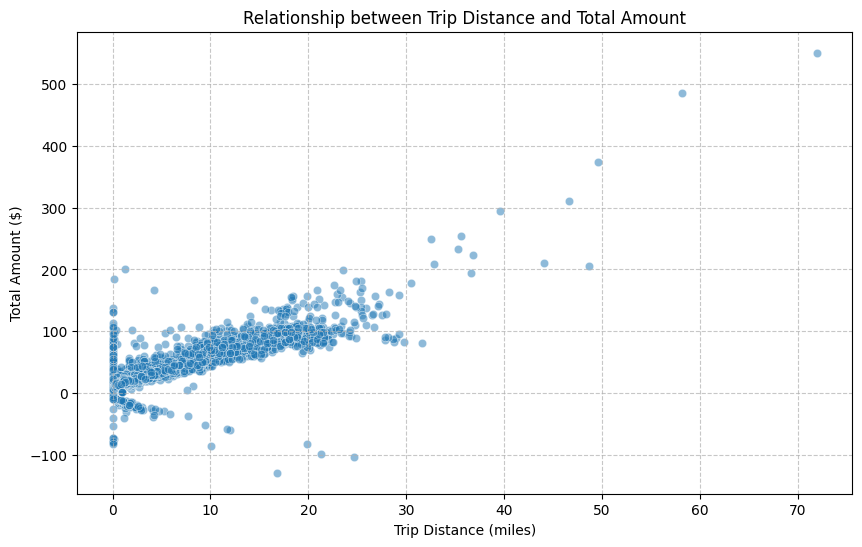

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='trip_distance', y='total_amount', alpha=0.5)

plt.title('Relationship between Trip Distance and Total Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Total Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The scatter plot reveals a strong positive correlation between distance and fare. However, significant outliers exist, including negative fare amounts and zero-distance trips with high costs. To improve model accuracy, I will filter the dataset to remove negative fares and examine trips with zero distance before training

<Figure size 1000x600 with 0 Axes>

C:\Users\vidha\AppData\Local\Temp\ipykernel_9228\200103357.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_surcharges.values, y=mean_surcharges.index, palette='viridis')


<Axes: ylabel='None'>

Text(0.5, 1.0, 'Average Contribution of Surcharges to Total Amount')

Text(0.5, 0, 'Average Amount ($)')

Text(0, 0.5, 'Surcharge Type')

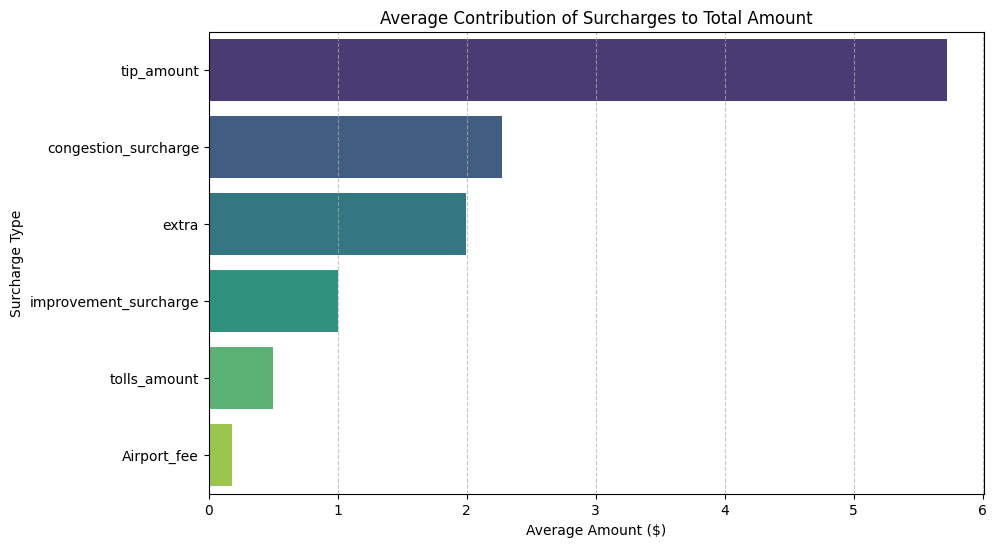

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of surcharge/additional fare columns
surcharge_cols = ['extra', 'tip_amount', 'tolls_amount',
                  'improvement_surcharge', 'congestion_surcharge', 'Airport_fee']

# Calculate the mean value of each surcharge to see their relative impact
mean_surcharges = train_df[surcharge_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=mean_surcharges.values, y=mean_surcharges.index, palette='viridis')

plt.title('Average Contribution of Surcharges to Total Amount')
plt.xlabel('Average Amount ($)')
plt.ylabel('Surcharge Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [17]:
original_count = len(train_df)

# 1. Remove Negative Values
# Fares and distances cannot be negative. These are likely system errors.
train_df = train_df[(train_df['total_amount'] > 0) & (train_df['trip_distance'] > 0)]

# We keep low-cost 0-distance trips as they might be base-fare cancellations.
train_df = train_df[~((train_df['trip_distance'] <= 0) & (train_df['total_amount'] > 50))]

# Using a 99th percentile cap or a hard limit (e.g., 60 miles) prevents
# the model from over-adjusting to rare long-distance trips.
q_dist = train_df['trip_distance'].quantile(0.99)
train_df = train_df[train_df['trip_distance'] < q_dist]

# 4. Remove extreme fare outliers
# Similarly, we cap the total_amount to remove extreme luxury/error rides.
q_fare = train_df['total_amount'].quantile(0.99)
train_df = train_df[train_df['total_amount'] < q_fare]

# 5. Logical Consistency: Fare vs Distance
# A taxi cannot travel 50 miles for $2. Remove cases where fare is too low for the distance.
train_df = train_df[train_df['total_amount'] > (train_df['trip_distance'] * 0.5)]

print(f"Removed {original_count - len(train_df)} outlier rows.")
print(f"Cleaned dataset shape: {train_df.shape}")

Removed 412 outlier rows.
Cleaned dataset shape: (9588, 17)


In [21]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Encode Categorical Features
le = LabelEncoder()
train_df['store_and_fwd_flag'] = le.fit_transform(train_df['store_and_fwd_flag'].astype(str))

# 2. Scale Numerical Features
scaler = StandardScaler()
# We scale everything except our target 'total_amount'
features_to_scale = ['trip_distance', 'passenger_count', 'extra',
                     'tip_amount', 'tolls_amount', 'congestion_surcharge']

train_df[features_to_scale] = scaler.fit_transform(train_df[features_to_scale])

print("Data is now Scaled and Encoded. Ready for Model Building!")

Data is now Scaled and Encoded. Ready for Model Building!
